
# LLM Tutorial on Healthcare with Synthetic Data (Synthea)

- **Reasoning methods**: Chain-of-Thought (CoT) & Tree-of-Thought (ToT) variants ✅  
- **ICL/Few-shot methods**: Zero-shot, Few-shot, Schema-aware, Reasoning+Few-shot ✅  
- **Downstream tasks**: Classification (disease flagging), Table-to-Text, Simplification ✅  
- **Bonus**: Combine reasoning + ICL + last-layer (self-consistency majority vote) ✅  




## 0. Environment Setup


In [3]:
!pip -q install pandas numpy jinja2 scikit-learn textstat matplotlib rouge-score bert-score --upgrade

In [4]:
!pip -q install openai --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 786.3/786.3 kB 10.7 MB/s eta 0:00:00


In [7]:
pip install --upgrade "numpy==1.26.4" "scipy>=1.10,<1.14" "scikit-learn==1.5.1"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 47.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.3/13.3 MB 62.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.6/38.6 MB 15.7 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.3.2
    Uninstalling numpy-2.3.2:
      Successfully uninstalled numpy-2.3.2
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.1
    Uninstalling scipy-1.16.1:
      Successfully uninstalled scipy-1.16.1
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.7.1
    Uninstalling scikit-learn-1.7.1:
      Successfully uninstalled scikit-learn-1.7.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the

In [1]:
import os

from typing import List, Dict, Any
import json, re, math, random
import pandas as pd
from jinja2 import Environment, DictLoader
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import textstat


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive



## 1. Load Synthea CSVs (100-patient sample)



In [2]:

# 👉 Edit this path to your local Synthea CSV folder
DATA_DIR = "/content/drive/MyDrive/MS-work/Assignment_LLM/synthea_sample_data"

import os
from pathlib import Path
DATA_DIR = Path(DATA_DIR)

def read_csv_safe(path: Path, name: str) -> pd.DataFrame:
    fp = path / f"{name}.csv"
    if not fp.exists():
        print(f"[WARN] Missing {fp}")
        return pd.DataFrame()
    return pd.read_csv(fp)

patients     = read_csv_safe(DATA_DIR, "patients")
conditions   = read_csv_safe(DATA_DIR, "conditions")
observations = read_csv_safe(DATA_DIR, "observations")
medications  = read_csv_safe(DATA_DIR, "medications")

print("patients:", patients.shape)
print("conditions:", conditions.shape)
print("observations:", observations.shape)
print("medications:", medications.shape)

assert not patients.empty, "patients.csv not found or empty. Fix DATA_DIR and rerun."


patients: (111, 28)
conditions: (4140, 7)
observations: (88156, 9)
medications: (4926, 13)


In [5]:
patients.columns

Index(['Id', 'BIRTHDATE', 'DEATHDATE', 'SSN', 'DRIVERS', 'PASSPORT', 'PREFIX',
       'FIRST', 'MIDDLE', 'LAST', 'SUFFIX', 'MAIDEN', 'MARITAL', 'RACE',
       'ETHNICITY', 'GENDER', 'BIRTHPLACE', 'ADDRESS', 'CITY', 'STATE',
       'COUNTY', 'FIPS', 'ZIP', 'LAT', 'LON', 'HEALTHCARE_EXPENSES',
       'HEALTHCARE_COVERAGE', 'INCOME'],
      dtype='object')

In [7]:
conditions.head()

,START,STOP,PATIENT,ENCOUNTER,SYSTEM,CODE,DESCRIPTION
0,2005-03-16,NaN,8c8e1c9a-b310-43c6-33a7-ad11bad21c40,8151e1b2-5789-578d-3e3a-d1d9b7c142ee,http://snomed.info/sct,224299000,Received higher education (finding)
1,2006-03-22,NaN,8c8e1c9a-b310-43c6-33a7-ad11bad21c40,6dce0dad-f85f-8a26-9583-f1bcdde4efc1,http://snomed.info/sct,266948004,Has a criminal record (finding)
2,2006-03-22,2021-04-07,8c8e1c9a-b310-43c6-33a7-ad11bad21c40,6dce0dad-f85f-8a26-9583-f1bcdde4efc1,http://snomed.info/sct,361055000,Misuses drugs (finding)
3,2012-03-28,2018-04-04,8c8e1c9a-b310-43c6-33a7-ad11bad21c40,6f2cf873-f64e-74a7-efba-6d772f418395,http://snomed.info/sct,160904001,Part-time employment (finding)
4,2012-03-28,NaN,8c8e1c9a-b310-43c6-33a7-ad11bad21c40,6f2cf873-f64e-74a7-efba-6d772f418395,http://snomed.info/sct,706893006,Victim of intimate partner abuse (finding)


In [8]:
observations.head()

,DATE,PATIENT,ENCOUNTER,CATEGORY,CODE,DESCRIPTION,VALUE,UNITS,TYPE
0,2017-12-22T02:04:53Z,8c8e1c9a-b310-43c6-33a7-ad11bad21c40,1f9f55cd-ae88-b9ab-15e1-927e73848ca3,vital-signs,8310-5,Body temperature,37.8,Cel,numeric
1,2018-04-04T06:04:53Z,8c8e1c9a-b310-43c6-33a7-ad11bad21c40,e2113f4b-89c7-a231-d3ae-a6a6b4f41566,vital-signs,8302-2,Body Height,185.6,cm,numeric
2,2018-04-04T06:04:53Z,8c8e1c9a-b310-43c6-33a7-ad11bad21c40,e2113f4b-89c7-a231-d3ae-a6a6b4f41566,vital-signs,72514-3,Pain severity - 0-10 verbal numeric rating [Sc...,0.0,{score},numeric
3,2018-04-04T06:04:53Z,8c8e1c9a-b310-43c6-33a7-ad11bad21c40,e2113f4b-89c7-a231-d3ae-a6a6b4f41566,vital-signs,29463-7,Body Weight,104.5,kg,numeric
4,2018-04-04T06:04:53Z,8c8e1c9a-b310-43c6-33a7-ad11bad21c40,e2113f4b-89c7-a231-d3ae-a6a6b4f41566,vital-signs,39156-5,Body mass index (BMI) [Ratio],30.3,kg/m2,numeric


In [9]:
medications.head()

,START,STOP,PATIENT,PAYER,ENCOUNTER,CODE,DESCRIPTION,BASE_COST,PAYER_COVERAGE,DISPENSES,TOTALCOST,REASONCODE,REASONDESCRIPTION
0,2016-04-11T11:48:33Z,2016-04-26T11:48:33Z,8c8e1c9a-b310-43c6-33a7-ad11bad21c40,8fa6c185-e44e-3e34-8bd8-39be8694f4ce,87741be8-2223-14c5-375d-976414fcd9aa,313782,Acetaminophen 325 MG Oral Tablet,119.52,0.0,1,119.52,NaN,NaN
1,2018-02-24T12:17:26Z,2018-03-21T12:17:26Z,8c8e1c9a-b310-43c6-33a7-ad11bad21c40,8fa6c185-e44e-3e34-8bd8-39be8694f4ce,0d6b6a0a-8f84-c860-ba6f-b241d14f55bf,849574,Naproxen sodium 220 MG Oral Tablet,91.72,0.0,1,91.72,NaN,NaN
2,2024-10-05T22:04:53Z,2024-10-23T22:04:53Z,8c8e1c9a-b310-43c6-33a7-ad11bad21c40,8fa6c185-e44e-3e34-8bd8-39be8694f4ce,fcd44e1e-0c9f-ab84-f187-11f0418849f4,313782,Acetaminophen 325 MG Oral Tablet,45.86,0.0,1,45.86,10509002.0,Acute bronchitis (disorder)
3,2017-06-19T01:38:45Z,2017-07-01T01:38:45Z,edc17058-55fb-08c7-12df-ece93a402e50,8fa6c185-e44e-3e34-8bd8-39be8694f4ce,3f9da7ae-4222-4094-dc1b-e30b9189d650,562251,Amoxicillin 250 MG / Clavulanate 125 MG Oral T...,252.65,0.0,1,252.65,444814009.0,Viral sinusitis (disorder)
4,2020-07-12T09:38:45Z,2020-07-25T09:38:45Z,edc17058-55fb-08c7-12df-ece93a402e50,8fa6c185-e44e-3e34-8bd8-39be8694f4ce,329ee98f-4c76-5422-653d-03fc8eb0bcf9,1043400,Acetaminophen 21.7 MG/ML / Dextromethorphan Hy...,61.15,0.0,1,61.15,10509002.0,Acute bronchitis (disorder)



## 2. Prepare Data In-Memory
- Derive **age** and a toy **diabetes label** (1 if E10/E11 or description contains "diabetes").  
- Build compact per-patient records: `{age, sex, diagnoses, meds, labs}`.  
- Create a **pseudo clinical note** for summarization/simplification tasks.  
- Create a **balanced sample** for experiments (e.g., up to 240 rows).


In [10]:

import numpy as np
from datetime import datetime

def derive_age_from_birthdate(df: pd.DataFrame, anchor="2020-01-01"):
    if "BIRTHDATE" not in df.columns:
        return df.assign(AGE=pd.Series([None]*len(df)))
    out = df.copy()
    out["BIRTHDATE"] = pd.to_datetime(out["BIRTHDATE"], errors="coerce")
    anchor = pd.Timestamp(anchor)
    out["AGE"] = ((anchor - out["BIRTHDATE"]).dt.days / 365.25).round().astype("Int64")
    return out

patients = derive_age_from_birthdate(patients)

def diabetes_patients(conditions: pd.DataFrame) -> set:
    if conditions.empty: return set()
    desc_hit = conditions["DESCRIPTION"].astype(str).str.lower().str.contains("diabetes", na=False)
    code_hit = conditions["CODE"].astype(str).str.match(r"^(E10|E11)")
    return set(conditions.loc[desc_hit | code_hit, "PATIENT"])

diab_ids = diabetes_patients(conditions)

def norm_list_str(xs) -> List[str]:
    out, seen = [], set()
    for x in xs:
        if pd.isna(x): continue
        s = str(x).strip()
        if not s or s in seen: continue
        seen.add(s); out.append(s)
    return out

def extract_numeric(s):
    try:
        if pd.isna(s): return None
        m = re.search(r"[-+]?\d*\.?\d+", str(s))
        return float(m.group()) if m else None
    except:
        return None

def build_labs(obs_df: pd.DataFrame, pid: str) -> Dict[str, Any]:
    """
    Build lab values for patient.
    """

    if obs_df.empty: return {}
    obs = obs_df.loc[obs_df["PATIENT"] == pid].copy()
    if obs.empty: return {}
    if "DATE" in obs.columns:
        obs["DATE"] = pd.to_datetime(obs["DATE"], errors="coerce")
        obs.sort_values("DATE", inplace=True)
    labs = {}

    a1c = obs[obs["DESCRIPTION"].str.contains("a1c", case=False, na=False) |
              obs["CODE"].astype(str).str.contains("4548-4", na=False)].tail(1)
    if not a1c.empty:
        labs["A1C_%"] = extract_numeric(a1c["VALUE"].iloc[0])

    ldl = obs[obs["DESCRIPTION"].str.contains("ldl", case=False, na=False) |
              obs["CODE"].astype(str).str.contains("13457-7", na=False)].tail(1)
    if not ldl.empty:
        labs["LDL_mg/dL"] = extract_numeric(ldl["VALUE"].iloc[0])

    bmi = obs[obs["DESCRIPTION"].str.contains("bmi", case=False, na=False)].tail(1)
    if not bmi.empty:
        labs["BMI"] = extract_numeric(bmi["VALUE"].iloc[0])

    sbp = obs[obs["DESCRIPTION"].str.contains("systolic", case=False, na=False)].tail(1)
    dbp = obs[obs["DESCRIPTION"].str.contains("diastolic", case=False, na=False)].tail(1)
    if not sbp.empty: labs["SBP_mmHg"] = extract_numeric(sbp["VALUE"].iloc[0])
    if not dbp.empty: labs["DBP_mmHg"] = extract_numeric(dbp["VALUE"].iloc[0])

    return labs

def build_record(pid: str) -> Dict[str, Any]:
    """
    Build patient record
    """
    prow = patients.loc[patients["Id"] == pid]
    if prow.empty: return {}
    prow = prow.iloc[0]
    sex = prow.get("GENDER", None)
    age = int(prow["AGE"]) if pd.notna(prow.get("AGE", None)) else None
    dx = norm_list_str(conditions.loc[conditions["PATIENT"] == pid, "DESCRIPTION"].tolist()) if not conditions.empty else []
    if not medications.empty:
        med_col = "DESCRIPTION" if "DESCRIPTION" in medications.columns else ("MEDICATION" if "MEDICATION" in medications.columns else None)
        meds = norm_list_str(medications.loc[medications["PATIENT"] == pid, med_col].tolist()) if med_col else []
    else:
        meds = []
    labs = build_labs(observations, pid)
    return {"patient_id": pid, "age": age, "sex": sex, "diagnoses": dx, "meds": meds, "labs": labs,
            "diabetes_label": 1 if pid in diab_ids else 0}

records = [build_record(pid) for pid in patients["Id"].tolist()]
df = pd.DataFrame(records)
print("records:", df.shape, "positive diabetes:", df["diabetes_label"].sum())


records: (111, 7) positive diabetes: 44


In [11]:
df.head()

,patient_id,age,sex,diagnoses,meds,labs,diabetes_label
0,8c8e1c9a-b310-43c6-33a7-ad11bad21c40,33,M,"[Received higher education (finding), Has a cr...","[Acetaminophen 325 MG Oral Tablet, Naproxen so...","{'BMI': 28.3, 'SBP_mmHg': 130.0, 'DBP_mmHg': 7...",0
1,edc17058-55fb-08c7-12df-ece93a402e50,34,M,"[Impacted molars (disorder), Chronic intractab...",[Amoxicillin 250 MG / Clavulanate 125 MG Oral ...,"{'A1C_%': 6.4, 'BMI': 27.4, 'SBP_mmHg': 133.0,...",1
2,80e7f50a-3e99-d5ac-cf97-f8a4b4f9e6c7,14,F,"[Medication review due (situation), Fracture o...","[sodium fluoride 0.0272 MG/MG Oral Gel, Acetam...","{'BMI': 54.2, 'SBP_mmHg': 101.0, 'DBP_mmHg': 8...",0
3,782001bc-f712-50ae-04f5-9a488f3ef4aa,28,F,"[Risk activity involvement (finding), Medicati...","[Loratadine 5 MG Chewable Tablet, NDA020800 0....","{'BMI': 29.5, 'SBP_mmHg': 102.0, 'DBP_mmHg': 8...",0
4,30e48e16-2df7-207e-7a3d-1650ef0c1ed8,64,F,"[Medication review due (situation), Primary de...","[sodium fluoride 0.0272 MG/MG Oral Gel, Acetam...","{'BMI': 16.8, 'SBP_mmHg': 123.0, 'DBP_mmHg': 7...",0


In [13]:

# Balanced sample for experiments (up to 240 rows if available)
N = 240
if df["diabetes_label"].nunique() > 1:
    df_sample = (df.groupby("diabetes_label", group_keys=False)
                   .apply(lambda x: x.sample(min(len(x), N//2), random_state=42))
                   .reset_index(drop=True))
else:
    df_sample = df.sample(min(N, len(df)), random_state=42).reset_index(drop=True)

def render_pseudo_note(rec: Dict[str, Any]) -> str:
    dx = ", ".join(rec.get("diagnoses", [])[:6]) or "no chronic diagnoses recorded"
    meds = ", ".join(rec.get("meds", [])[:6]) or "no active medications"
    labs = rec.get("labs", {})
    bits = []
    for k, v in labs.items():
        if v is None: continue
        unit = " mg/dL" if k.endswith("_mg/dL") else (" mmHg" if k.endswith("_mmHg") else ("%"
                 if k.endswith("_%") else ""))
        bits.append(f"{k.replace('_',' ').replace('%','')}: {v}{unit}")
    labs_txt = "; ".join(bits) or "no recent labs available"
    return (f"Assessment & Plan:\n"
            f"Patient is a {rec.get('age','N/A')}-year-old {rec.get('sex','N/A')} with {dx}. "
            f"Current medications include {meds}. Recent labs: {labs_txt}. "
            f"Focus on risk factor control, medication adherence, and appropriate follow-up.")

df_sample["pseudo_note"] = df_sample.apply(lambda r: render_pseudo_note(r.to_dict()), axis=1)



                                                                0  \
patient_id                   80cca49f-29f9-d04f-851d-84b95f863793   
age                                                            16   
sex                                                             F   
diagnoses       [Medication review due (situation), Gingivitis...   
meds            [sodium fluoride 0.0272 MG/MG Oral Gel, Natazi...   
labs            {'BMI': 25.7, 'SBP_mmHg': 107.0, 'DBP_mmHg': 6...   
diabetes_label                                                  0   
pseudo_note     Assessment & Plan:\nPatient is a 16-year-old F...   

                                                                1  
patient_id                   3270397c-dfa3-6cea-f2ec-be21ade6c52c  
age                                                            26  
sex                                                             M  
diagnoses       [Received higher education (finding), Transpor...  
meds                                  

/tmp/ipython-input-2212654520.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(len(x), N//2), random_state=42))


In [17]:
print(df_sample["pseudo_note"][0])

Assessment & Plan:
Patient is a 16-year-old F with Medication review due (situation), Gingivitis (disorder), Acute infective cystitis (disorder), Burn injury (morphologic abnormality), Epidermal burn of skin (disorder), Acute bronchitis (disorder). Current medications include sodium fluoride 0.0272 MG/MG Oral Gel, Natazia 28 Day Pack, sulfamethoxazole 800 MG / trimethoprim 160 MG Oral Tablet, Acetaminophen 325 MG Oral Tablet, Seasonique 91 Day Pack, Levora 0.15/30 28 Day Pack. Recent labs: BMI: 25.7; SBP mmHg: 107.0 mmHg; DBP mmHg: 68.0 mmHg. Focus on risk factor control, medication adherence, and appropriate follow-up.


In [40]:
# Sample helpers

from typing import Optional

def sample_random(df: pd.DataFrame, n: int, random_state: Optional[int] = None):
    n = min(n, len(df))
    return df.sample(n=n, random_state=random_state).reset_index(drop=True)

def sample_balanced(df: pd.DataFrame, by: str, n: int, random_state: Optional[int] = None):
    """
    Balanced sample across classes in column `by`.
    If a class is small, takes as many as available.
    """
    if by not in df.columns or df[by].nunique() < 2:
        return sample_random(df, n, random_state)
    per_class = max(1, n // df[by].nunique())
    parts = (
        df.groupby(by, group_keys=False)
          .apply(lambda g: g.sample(min(len(g), per_class), random_state=random_state))
          .reset_index(drop=True)
    )
    # if we undershot due to tiny classes, top up randomly from the remainder
    if len(parts) < n:
        remainder = df.drop(parts.index, errors="ignore")
        topup = sample_random(remainder, n - len(parts), random_state)
        parts = pd.concat([parts, topup], ignore_index=True)
    return parts.reset_index(drop=True)



## 3. Prompts (Zero-shot, Few-shot, Reasoning/CoT, Tree-of-Thought)
We define compact templates inline and render them with Jinja2.  
We will test **zero-shot**, **few-shot**, **reasoning (CoT)**, and **ToT (two candidates → select)**.


In [18]:

PROMPTS = {
"table2text_zero": """System:
You write concise clinician-facing patient snapshots. Do not invent fields.
User:
You’ll receive a JSON record delimited by <record>. Use only its content.
Rules:
- Cover: Problems, Meds, Labs (flag highs/lows), Risks, Next Steps.
- Quote numeric values with units if present.
- If info is missing, say “not recorded”.
- Keep to 120–150 words. No headings. No lists.
<record>
{{ record_json }}
</record>""",

"table2text_fewshot": """System:
You write concise clinician-facing patient snapshots. Do not invent fields.
User:
Example
<record>
{"age":67,"sex":"F","diagnoses":["hypertension"],"meds":["lisinopril"],"labs":{"SBP_mmHg":154,"DBP_mmHg":92}}
</record>
Output
“67-year-old female with hypertension on lisinopril. BP 154/92 mmHg (elevated) … Next steps: …”
Now do the same for:
<record>
{{ record_json }}
</record>
(120–150 words; no made-up fields.)""",

"table2text_reasoned": """System:
Produce a final snapshot only. Use the scratch area to check facts.
User:
<record>
{{ record_json }}
</record>
Scratch (do not reveal): list the fields you will use.
Final (output only this): 120–150 words; Problems, Meds, Labs (flag), Risks, Next Steps; no invented data.""",

"disease_cls_zero": """System:
You are a careful clinical classifier. If uncertain, return "unsure".
User:
Classify the record between {"yes","no","unsure"} for diabetes, and estimate risk {"low","medium","high"}.
Decision rules:
- Existing diabetes diagnosis → "yes".
- HbA1c ≥ 6.5% → "yes" (cite value).
- HbA1c 6.0–6.4% with other diabetes signals → "unsure".
- No signal → "no".
Output JSON ONLY matching this schema:
{"label":"yes|no|unsure","risk":"low|medium|high","rationale":"≤30 words citing fields (e.g., A1C 7.2%)"}
Record:
<record>
{{ record_json }}
</record>""",

"disease_cls_fewshot": """System:
You are a careful clinical classifier. If uncertain, return "unsure".
User:
Classify the record between {"yes","no","unsure"} for diabetes, and estimate risk {"low","medium","high"}.
Decision rules:
- Existing diabetes diagnosis → "yes".
- HbA1c ≥ 6.5% → "yes" (cite value).
- HbA1c 6.0–6.4% with other diabetes signals → "unsure".
- No signal → "no".
Output JSON ONLY:
{"label":"yes|no|unsure","risk":"low|medium|high","rationale":"≤30 words citing fields"}
Example In:
{"age":54,"sex":"F","diagnoses":["hypertension"],"labs":{"A1C_%":7.1}}
Example Out:
{"label":"yes","risk":"medium","rationale":"A1C 7.1% ≥ 6.5% threshold."}
Now classify:
<record>
{{ record_json }}
</record>""",

"disease_cls_reasoned": """System:
You are a careful clinical classifier. If uncertain, return "unsure".
User:
First, list the signals that support or refute diabetes based on the record. Then output the final JSON ONLY as last line:
{"label":"yes|no|unsure","risk":"low|medium|high","rationale":"≤30 words citing fields"}.
Record:
<record>
{{ record_json }}
</record>""",

"simplify_zero": """System:
You write plain-language health explanations.
User:
Rewrite the text for a {{ audience }} at about grade {{ grade_level }}.
Rules:
- Keep meaning; avoid jargon; define medical terms simply.
- Use exactly three headings: "What it means", "What to do", "When to seek help".
- 6–8 short sentences total.
- If numbers appear (A1C, BP), keep them; don’t add new ones.
Text:
<source>
{{ source_text }}
</source>""",

"summarize_reasoned": """System:
You summarize clinical text faithfully.
User:
List key problems, pertinent meds, abnormal labs, and plan as bullets (scratch). Then output a 4–6 sentence summary ONLY.
Text:
<note>
{{ note_text }}
</note>"""
}

env = Environment(loader=DictLoader(PROMPTS))
print("Prompts loaded:", list(PROMPTS.keys()))


Prompts loaded: ['table2text_zero', 'table2text_fewshot', 'table2text_reasoned', 'disease_cls_zero', 'disease_cls_fewshot', 'disease_cls_reasoned', 'simplify_zero', 'summarize_reasoned']



## 4. OPENAI backend


In [ ]:
OPENAI_KEY='###'

In [39]:

GEN_BACKEND = "openai"  # or "ollama"
OPENAI_MODEL = "gpt-5-mini"

def gen_text(prompt: str, temperature: float=0.3) -> str:
    if GEN_BACKEND == "openai":
        from openai import OpenAI
        client = OpenAI(api_key=OPENAI_KEY)
        resp = client.chat.completions.create(
            model=OPENAI_MODEL,
            messages=[{"role":"user","content":prompt}],
            temperature=temperature,
        )
        return resp.choices[0].message.content.strip()
    else:
        raise ValueError("GEN_BACKEND must be 'openai'")



## 5. Experiments Matrix

- **Tasks**: table-to-text, disease classification, simplification  
- **Methods**: zero-shot, few-shot, reasoning (CoT), reasoning+few-shot  
- **Bonus**: For classification, add **self-consistency** (3 samples → majority vote).  
Additionally, **ToT** for table-to-text: generate two candidates → have model pick best.


In [23]:

def render(tpl_name: str, **kwargs) -> str:
    return env.get_template(tpl_name).render(**kwargs)

def safe_json(s: str):
    s = s.strip().strip("`")
    s = re.sub(r"^```json|```$", "", s).strip()
    try:
        return json.loads(s)
    except:
        # try last JSON-looking line (for reasoning prompt last-line JSON)
        lines = [ln.strip() for ln in s.splitlines() if "{" in ln and "}" in ln]
        for ln in lines[::-1]:
            try:
                return json.loads(ln)
            except:
                continue
        return {"parse_error": True, "raw": s}


In [50]:
def run_table2text(df_in: pd.DataFrame, n=60, method="zero", temperature=1, seed: Optional[int]=None):
    sub = sample_random(df_in, n, random_state=seed)
    rows = []
    for _, r in sub.iterrows():
        rec = {"age": r["age"], "sex": r["sex"], "diagnoses": r["diagnoses"], "meds": r["meds"], "labs": r["labs"]}
        if method == "zero":
            prompt = render("table2text_zero", record_json=json.dumps(rec, ensure_ascii=False))
        elif method == "fewshot":
            prompt = render("table2text_fewshot", record_json=json.dumps(rec, ensure_ascii=False))
        elif method == "reasoned":
            prompt = render("table2text_reasoned", record_json=json.dumps(rec, ensure_ascii=False))
        elif method == "tot":
            p1 = render("table2text_reasoned", record_json=json.dumps(rec, ensure_ascii=False))
            p2 = render("table2text_fewshot",  record_json=json.dumps(rec, ensure_ascii=False))
            c1 = gen_text(p1, temperature); c2 = gen_text(p2, temperature)
            judge = f"You are a clinician. Pick the better snapshot (A or B) based on factuality, correct units, completeness. Respond 'A' or 'B' only.\nA) {c1}\nB) {c2}\n"
            pick = gen_text(judge, temperature=1)
            out = c1 if pick.strip().upper().startswith("A") else c2
            rows.append({"id": r["patient_id"], "task":"table2text", "method":method, "output":out})
            continue
        else:
            raise ValueError("method must be zero|fewshot|reasoned|tot")
        out = gen_text(prompt, temperature)
        rows.append({"id": r["patient_id"], "task":"table2text", "method":method, "output":out})
    return pd.DataFrame(rows)



In [43]:
t2t_zero = run_table2text(df_sample, n=1, method="zero")
t2t_zero.head()

,id,task,method,output
0,edc17058-55fb-08c7-12df-ece93a402e50,table2text,zero,"34-year-old M with impacted molars, gingivitis..."


In [47]:
def run_classify(df_in: pd.DataFrame, n=120, method="fewshot", samples=5, temperature=1, seed: Optional[int]=None):
    # keep classes balanced for fair metrics
    sub = sample_balanced(df_in, by="diabetes_label", n=n, random_state=seed)
    print(sub)
    rows = []
    for _, r in sub.iterrows():
        rec = {"age": r["age"], "sex": r["sex"], "diagnoses": r["diagnoses"], "meds": r["meds"], "labs": r["labs"]}
        if method == "zero":
            prompt = render("disease_cls_zero", record_json=json.dumps(rec, ensure_ascii=False))
            outs = [safe_json(gen_text(prompt, temperature))]
        elif method == "fewshot":
            prompt = render("disease_cls_fewshot", record_json=json.dumps(rec, ensure_ascii=False))
            outs = [safe_json(gen_text(prompt, temperature)) for _ in range(samples)]
        elif method == "reasoned":
            prompt = render("disease_cls_reasoned", record_json=json.dumps(rec, ensure_ascii=False))
            outs = [safe_json(gen_text(prompt, temperature)) for _ in range(samples)]
        elif method == "reasoned_fewshot":
            base = PROMPTS["disease_cls_reasoned"] + \
                   '\n\nExample In:\n{"age":54,"sex":"F","diagnoses":["hypertension"],"labs":{"A1C_%":7.1}}\n' + \
                   'Example Out:\n{"label":"yes","risk":"medium","rationale":"A1C 7.1% ≥ 6.5% threshold."}\n'
            prompt = Environment(loader=DictLoader({"tmp": base})).get_template("tmp").render(
                record_json=json.dumps(rec, ensure_ascii=False)
            )
            outs = [safe_json(gen_text(prompt, temperature)) for _ in range(samples)]
        else:
            raise ValueError("method must be zero|fewshot|reasoned|reasoned_fewshot")
        labels = [o.get("label","unsure") for o in outs if not o.get("parse_error")]
        maj = max(set(labels), key=labels.count) if labels else "unsure"
        rows.append({
            "id": r["patient_id"], "y_true": int(r["diabetes_label"]), "task":"classify",
            "method": f"{method}+SC{samples}" if samples>1 else method,
            "pred_json": json.dumps({"label": maj, "votes": labels}, ensure_ascii=False)
        })
    return pd.DataFrame(rows)

# Example small run
clf_few  = run_classify(df_sample, n=5, method="fewshot", samples=5)



/tmp/ipython-input-4021508396.py:19: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(min(len(g), per_class), random_state=random_state))


                             patient_id  age sex  \
0  57b21dea-ff00-6c3e-92d9-91c7627f53b2    7   F   
1  c3dae8db-25ee-c40b-c605-600fad411d34   25   M   
2  119e46a1-9323-916b-4152-e0daedb48f23   45   F   
3  5f9bfe93-062d-ca4b-5389-f8cac604a7e3   55   F   
4  0a1bd9a2-fc21-7ad3-3d85-cf31b68eec28   34   F   

                                           diagnoses  \
0  [Medication review due (situation), Otitis med...   
1  [Only received primary school education (findi...   
2  [Risk activity involvement (finding), Educated...   
3  [Risk activity involvement (finding), Received...   
4  [Received higher education (finding), Stress (...   

                                                meds  \
0  [Amoxicillin 500 MG Oral Tablet, Ibuprofen 100...   
1  [Loratadine 5 MG Chewable Tablet, NDA020800 0....   
2  [Amoxicillin 250 MG / Clavulanate 125 MG Oral ...   
3  [Simvastatin 10 MG Oral Tablet, Trinessa 28 Da...   
4  [Acetaminophen 300 MG / Hydrocodone Bitartrate...   

             

In [48]:
clf_few.head()

,id,y_true,task,method,pred_json
0,57b21dea-ff00-6c3e-92d9-91c7627f53b2,0,classify,fewshot+SC5,"{""label"": ""no"", ""votes"": [""no"", ""no"", ""no"", ""n..."
1,c3dae8db-25ee-c40b-c605-600fad411d34,0,classify,fewshot+SC5,"{""label"": ""no"", ""votes"": [""no"", ""no"", ""no"", ""n..."
2,119e46a1-9323-916b-4152-e0daedb48f23,1,classify,fewshot+SC5,"{""label"": ""yes"", ""votes"": [""yes"", ""yes"", ""yes""..."
3,5f9bfe93-062d-ca4b-5389-f8cac604a7e3,1,classify,fewshot+SC5,"{""label"": ""unsure"", ""votes"": [""unsure"", ""unsur..."
4,0a1bd9a2-fc21-7ad3-3d85-cf31b68eec28,1,classify,fewshot+SC5,"{""label"": ""unsure"", ""votes"": [""unsure"", ""unsur..."


In [34]:
def run_simplify(df_in: pd.DataFrame, n=100, audience="older adult", grade_level=6, method="zero", temperature=1, seed: Optional[int]=None):
    sub = sample_random(df_in, n, random_state=seed)
    rows = []
    for _, r in sub.iterrows():
        prompt = render("simplify_zero", audience=audience, grade_level=grade_level, source_text=r["pseudo_note"])
        out = gen_text(prompt, temperature)
        rows.append({"id": r["patient_id"], "task":"simplify", "method": f"{method}-g{grade_level}", "output": out})
    return pd.DataFrame(rows)


# Example small run
simp = run_simplify(df_sample, n=1, audience="older adult", grade_level=6, method="zero")
simp.head()


,id,task,method,output
0,e1c6b5c4-34b7-7296-56ed-4c634e93deb9,simplify,zero-g6,What it means\n- You are an adult woman with s...



## 6. Evaluation
- **Classification**: coverage (answered fraction), accuracy, precision/recall/F1, confusion matrix.  
- **Table-to-Text**: fabricated fields (heuristic), unit sanity for LDL, readability.  
- **Simplification**: readability (grade), jargon rate.


In [37]:

def evaluate_classification(df_preds: pd.DataFrame):
    dfp = df_preds.copy()
    dfp["label"] = dfp["pred_json"].apply(lambda s: json.loads(s).get("label","unsure"))
    answered = dfp[dfp["label"].isin(["yes","no"])]
    coverage = len(answered)/len(dfp) if len(dfp)>0 else 0.0
    mapping = {"yes":1,"no":0}
    y_true = answered["y_true"].values
    y_hat  = answered["label"].map(mapping).values
    print("Coverage:", round(coverage,3)) # how often the model is confident enough to decide.
    if len(answered)>0:
        print(classification_report(y_true, y_hat, digits=3))
        print("Confusion matrix:\n", confusion_matrix(y_true, y_hat))
    return coverage

def evaluate_table_to_text(df_t2t: pd.DataFrame):
    """
    Check quality of table-to-text output. (structured -> narrative).

    - Avg fabricated fields
    - Fraction with correct LDL units
    - Avg reading grade
    """
    def eval_row(text: str):
        allowed = {"age","sex","diagnoses","meds","labs"}
        fabricated = sum(1 for m in re.findall(r"\b([A-Za-z_]+)\s*:", text) if m.lower() not in allowed)
        mentions_ldl = bool(re.search(r"\bldl\b", text, flags=re.I))
        unit_ok = (not mentions_ldl) or ("mg/dL" in text)
        grade = textstat.flesch_kincaid_grade(text)
        return fabricated, int(unit_ok), grade
    mets = df_t2t["output"].apply(lambda s: pd.Series(eval_row(s), index=["fabricated_fields","unit_ok","fk_grade"]))
    out = pd.concat([df_t2t[["method"]].reset_index(drop=True), mets.reset_index(drop=True)], axis=1)
    print(out.groupby("method").agg({"fabricated_fields":"mean","unit_ok":"mean","fk_grade":"mean"}))
    return out

def evaluate_simplification(df_simp: pd.DataFrame):
    """
    Evaluate simplification outputs for patient notes.
    - Avg reading grade
    - Avg jargon rate
    """
    MED_TERMS = {"hypertension","diabetes","insulin","statin","metformin","ischemia","myocardial","a1c","ldl","copd"}
    def eval_row(text: str):
        grade = textstat.flesch_kincaid_grade(text)
        words = re.findall(r"[A-Za-z]+", text.lower())
        jargon = sum(1 for w in words if w in MED_TERMS)/max(1,len(words))
        return grade, jargon
    mets = df_simp["output"].apply(lambda s: pd.Series(eval_row(s), index=["fk_grade","jargon_rate"]))
    out = pd.concat([df_simp[["method"]].reset_index(drop=True), mets.reset_index(drop=True)], axis=1)
    print(out.groupby("method").agg({"fk_grade":"mean","jargon_rate":"mean"}))
    return out



## 7. Plots
bars for **coverage**, **fabricated fields**, and **readability**.


In [36]:

def plot_coverage(coverage: float, label="fewshot+SC3"):
    plt.bar([label],[coverage]); plt.ylim(0,1); plt.title("Classification Coverage"); plt.show()

def plot_group_bar(df_eval: pd.DataFrame, col: str, title: str, lower_is_better=False):
    agg = df_eval.groupby("method")[col].mean().sort_values(ascending=lower_is_better)
    agg.plot(kind="bar"); plt.title(title); plt.show()



## 8.Experiments


In [51]:

# === RUNS ===
# Table-to-Text
t2t_zero = run_table2text(df_sample, n=20, method="zero")
t2t_few  = run_table2text(df_sample, n=20, method="fewshot")
t2t_cot  = run_table2text(df_sample, n=20, method="reasoned")
t2t_tot  = run_table2text(df_sample, n=20, method="tot")
t2t_all = pd.concat([t2t_zero, t2t_few, t2t_cot, t2t_tot], ignore_index=True)

# Classification
clf_rf   = run_classify(df_sample, n=60, method="reasoned_fewshot", samples=3)
clf_all = clf_rf

# Simplification
simp = run_simplify(df_sample, n=20, audience="older adult", grade_level=6, method="zero")


/tmp/ipython-input-4021508396.py:19: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(min(len(g), per_class), random_state=random_state))


                              patient_id  age sex  \
0   0fca905f-391c-08d3-4b93-b53f69b9da53   42   M   
1   2da86d63-34ae-b887-ddff-8f6f1e6990f1   19   M   
2   0e5401fd-b241-3c84-066e-2b88e5ddafc7   37   F   
3   7ddb0322-da41-c9d3-2018-4581109426b2   36   M   
4   37895f0e-877f-7ea7-aa1b-0b69fcd11385  104   M   
5   0851b7fb-87a8-3edc-1e11-8dcb03824dde   47   F   
6   a331b5bc-cbea-a205-a8bf-dbf3255ef36a   13   M   
7   103b63c9-9ef8-6d25-771e-2fba661489a1   47   F   
8   74a4cdcf-7cc0-7658-e1e0-cd1182d5f205    2   M   
9   1e9713a5-742f-aca0-cf95-446338fdc57f    9   F   
10  1c1ab155-7314-095d-1641-06efd2cd0873   13   M   
11  782001bc-f712-50ae-04f5-9a488f3ef4aa   28   F   
12  2bc26ad6-ad32-0bb0-f964-0fe271fdf054   25   F   
13  3477fa4e-a09a-e779-5d56-eeb00dee758b   44   F   
14  8c8e1c9a-b310-43c6-33a7-ad11bad21c40   33   M   
15  49424eb4-e2ba-40b5-0e2b-2c2d742cce4b   12   M   
16  7785daad-accb-cb33-7d8f-2faebf8eb639   55   F   
17  97a046ab-d147-2707-d4cd-cba26c5360ad   54 

Coverage: 0.833
              precision    recall  f1-score   support

           0      0.488     1.000     0.656        20
           1      1.000     0.300     0.462        30

    accuracy                          0.580        50
   macro avg      0.744     0.650     0.559        50
weighted avg      0.795     0.580     0.539        50

Confusion matrix:
 [[20  0]
 [21  9]]


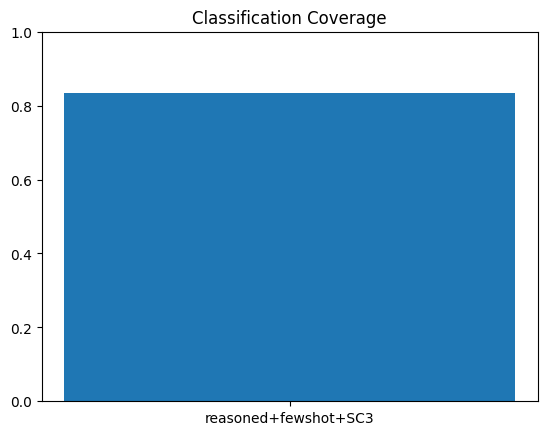

          fabricated_fields  unit_ok   fk_grade
method                                         
fewshot                2.90      1.0  16.419648
reasoned               3.10      1.0  17.395038
tot                    3.45      1.0  16.275174
zero                   2.80      1.0  14.204639


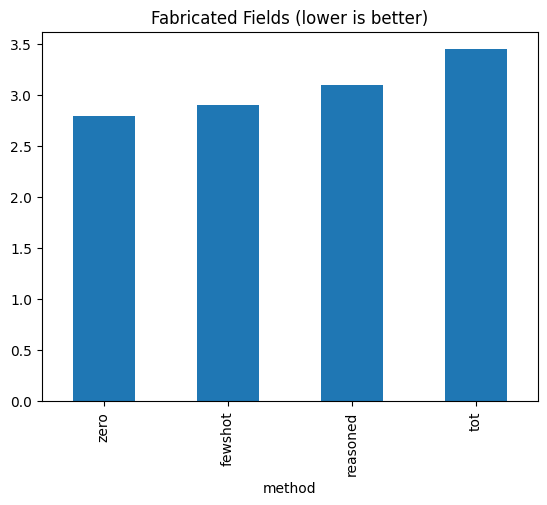

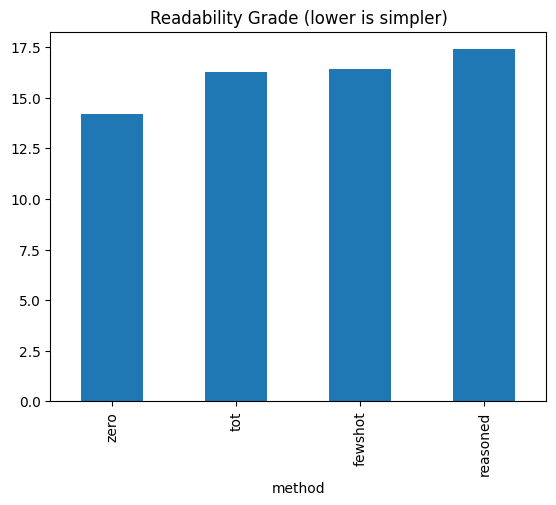

         fk_grade  jargon_rate
method                        
zero-g6  7.163024     0.003968


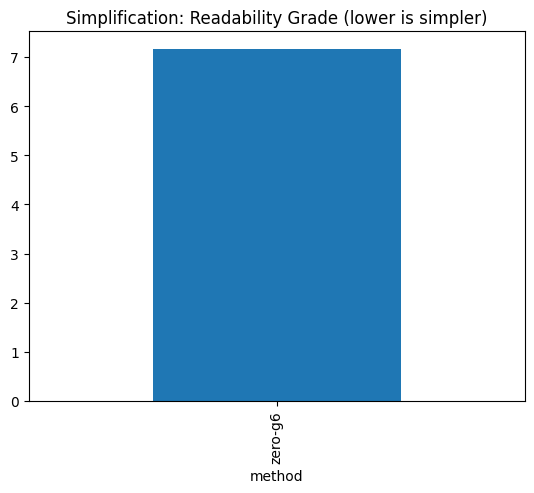

In [52]:
# === EVAL ===
if len(clf_all):
    cov = evaluate_classification(clf_all)
    plot_coverage(cov, "reasoned+fewshot+SC3")
if len(t2t_all):
    t2t_eval = evaluate_table_to_text(t2t_all)
    plot_group_bar(t2t_eval, "fabricated_fields", "Fabricated Fields (lower is better)", lower_is_better=True)
    plot_group_bar(t2t_eval, "fk_grade", "Readability Grade (lower is simpler)", lower_is_better=True)
if len(simp):
    simp_eval = evaluate_simplification(simp)
    plot_group_bar(simp_eval, "fk_grade", "Simplification: Readability Grade (lower is simpler)", lower_is_better=True)
